 # Analisi delle comunità della rete Immigrazione 2023
 In questo capitolo, procederemo con l'analisi delle comunità A e B della rete. In particolare confronteremo le metriche di centralità, defininendo le proprietà topologiche dei due gruppi.

 ## Studio delle distibuzioni di centralita per A e B
 Abbiamo calcolato la distibuzione delle misure di centralità della rete, evidenziando le differenze tra le due comunità.
 Le misure (ad eccezione della coreness) sono state normalizzate, come di seguito.
Le misure calcolate sono le seguenti e ci permettono di rispondere alle relative domande:
- L'**eigenvector centrality** misura l'importanza del nodo in relazione all'importanza dei nodi a cui è connesso; è definita dalla formula ricorsiva:
$$ x_{i} = {1 \over \lambda} \sum_{j}A_{ij} x_j $$
normalizzata come $ x_i^{norm} = {x_i \over \max_j(x_j)} $,
 - La **coreness** calcola la scomposizione in $k_{\text{core}}$, dove il $k_{\text{core}}$ è il sottografo massimale in cui tutti i nodi hanno grado interno maggiore o uguale a $k$.
 $$ \text{coreness}(v) = \max\{k | v \in k_{\text{core}}\} $$

dove $x_i$ è la centralità del nodo $i$ e $A_{ij}$ è la matrice di adiacenza del grafo. 

*Qual è la struttura gerarchica della rete? E' simmetrica nelle due comunità? E' possibile identificare un core di nodi più densamente connessi?*

 - La **closeness centrality** misura quanto un nodo sia "vicino" agli altri nodi del grafo:
 $$ \text{closeness}(v) = {(N-1)\over \sum_{u\neq v}d(u,v)}$$
 dove $N$ è il numero di nodi e $d(u,v)$ è lo shortest path tra i nodi $u$ e $v$.
 - La **betweenness centrality** misura quante volte un nodo si trova sul cammino minimo tra tutte le possibili coppie di altri nodi:
 $$\text{betweenness}(v) = {2 \over (N-1)(N-2)}\sum_{u\neq v, k \neq v}{\sigma_{uk}(v) \over \sigma_{uk}}$$
 dove $\sigma_{uk}$ è il numero di shortest paths tra il nodo $u$ e $k$, mentre $\sigma_{uk}(v)$ è il numero di shortest paths che passano per il nodo $v$. La normalizzazione tiene conto di tutte le possibili coppie non ordinate $(u, v)$. Ci permette di studiare come sono dsitribuiti i nodi fondamentali per la connessione dell'intera rete.

*Come si presenta la struttura geometrica della rete? Ci sono nodi fondamentali per il flusso di informazione all'interno della rete e tra le due comunità?*

In [1]:
from utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import igraph as ig
import pandas as pd

In [2]:
graph_path = DATA_DIR + 'Centrality/Centrality_immigration_23.graphml'
G = load_graph(graph_path)

/home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Code/utils.py:25: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


Abbiamo realizzato due istogrammi relativi ad A e B, per ogni centralità. 
Ogni istogramma misura il numero di nodi della comunità che presentano uno specifico valore della metrica calcolata sull'intera rete.

In [ ]:
def plot_centralities(G: ig.Graph, savefile=''):
    ''' Calcola le misure di centralità sull'intera rete e poi realizza un istogramma con i conteggi divisi per comunità
    '''
    metrics = ['coreness', 'eigenvector', 'closeness', 'betweenness']
    fig, axes = plt.subplots(2, 2, figsize=(15,9))

    for ax, m in zip(axes.flat, metrics):
        values = np.array(G.vs[m], dtype=float)

        # Separa i due gruppi
        maskA = [group == 'A' for group in G.vs['group']]
        maskB = [group == 'B' for group in G.vs['group']]
        valuesA = np.array(values[maskA])
        valuesB = np.array(values[maskB])

        # Rimuovi eventuali zeri (per logaritmo)
        valuesA = valuesA[valuesA > 0]
        valuesB = valuesB[valuesB > 0]

        if m == 'coreness':
            # calcolo della mediana 
            medA_plot = np.median(valuesA)
            medB_plot = np.median(valuesB)
            # Coreness è intera: usiamo i valori direttamente come bin edges
            min_val = min(valuesA.min(), valuesB.min())
            max_val = max(valuesA.max(), valuesB.max())
            bins = np.arange(min_val, max_val + 2) - 0.5  # centri sugli interi
            # Calcola istogrammi 
            histA, edgesA = np.histogram(valuesA, bins=bins, density=False)
            histB, edgesB = np.histogram(valuesB, bins=bins, density=False)
            bin_centers = (bins[:-1] + bins[1:]) / 2
            bin_widths = np.diff(bins)
            ylabel = 'coreness'
            # Non trasformiamo l'asse y
        else:
            # Trasformazione logaritmica per le altre metriche
            logA = np.log10(valuesA)
            logB = np.log10(valuesB)
            # calcolo della mediana
            medA_plot = np.median(logA)
            medB_plot = np.median(logB)

            all_log = np.concatenate([logA, logB])
            bins = np.linspace(all_log.min(), all_log.max(), 40)
            histA, edgesA  = np.histogram(logA, bins=bins, density=False)
            histB, edgesB = np.histogram(logB, bins=bins, density=False)
            bin_centers = (bins[:-1] + bins[1:]) / 2
            bin_widths = np.diff(bins)
            ylabel = m
        
        # Istogrammi specchiati: A a sinistra (larghezza negativa), B a destra (positiva)
        ax.barh(bin_centers, width=-histA, height=bin_widths,
                color=color_group['A'], alpha=0.5, edgecolor='white', label='A')
        ax.barh(bin_centers, width=histB, height=bin_widths,
                color=color_group['B'], alpha=0.5, edgecolor='white', label='B')
    
        max_density = max(histA.max(), histB.max()) * 1.3
        ax.set_xlim(-max_density, max_density)

        # PLOT mediane
        ax.hlines(medA_plot, xmin=-max_density, xmax=0,
                  color=color_group['A'], linestyle='--', linewidth=1.5,
                  label=f'Mediana A')
        # B: linea da 0 verso destra (positivo)
        ax.hlines(medB_plot, xmin=0, xmax=max_density,
                  color=color_group['B'], linestyle='--', linewidth=1.5,
                  label=f'Mediana B')
        

        # Imposta l'asse x in modo simmetrico
        max_density = max(histA.max(), histB.max()) * 1.3
        ax.set_xlim(-max_density, max_density)
        
        ax.set_xlabel('Conteggi')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3, axis='x')   # solo griglie verticali
        

        # Personalizza le etichette dell'asse y per le metriche logaritmiche
        if m != 'coreness':
            # Mostra alcune etichette in scala originale
            yticks_log = np.linspace(bins.min(), bins.max(), 5)
            ax.set_yticks(yticks_log)
            ax.set_yticklabels([f'$10^{{{v:.1f}}}$' for v in yticks_log])
            hist_max = max(((histA.max()+99) // 100)*100, ((histB.max()+99)//100)*100)
            xticks = np.linspace(-hist_max, hist_max, 5)
            ax.set_xticks(xticks)
            ax.set_xticklabels(map(int,abs(xticks)))
        else:
            # Per coreness, mostra valori interi
            ax.set_yticks(np.arange(0, max_val+1, 5))
            ax.set_xscale('symlog')
            ticks_exp = [-1000, -100, -10, -1, 0, 1, 10, 100, 1000]
            ax.set_xticks(ticks_exp)
            ax.set_xticklabels(['$10^3$', '$10^2$', '10', '1', '0', '1', '10', '$10^2$', '$10^3$'])
            ax.legend(frameon=True, bbox_to_anchor=(0, 1.4), loc='upper left')

        ax.set_title(m.capitalize(), fontsize=FONTSIZE_TITLE)    
        ax.tick_params(direction='out')

    
    fig.suptitle("Distribuzione misure di centralità per le due comunità", fontsize=FONTSIZE_SUPTITLE, y=1.02)
    plt.tight_layout()
    if savefile:
        plt.savefig(savefile)
    else:
        plt.show()
    plt.close(fig)


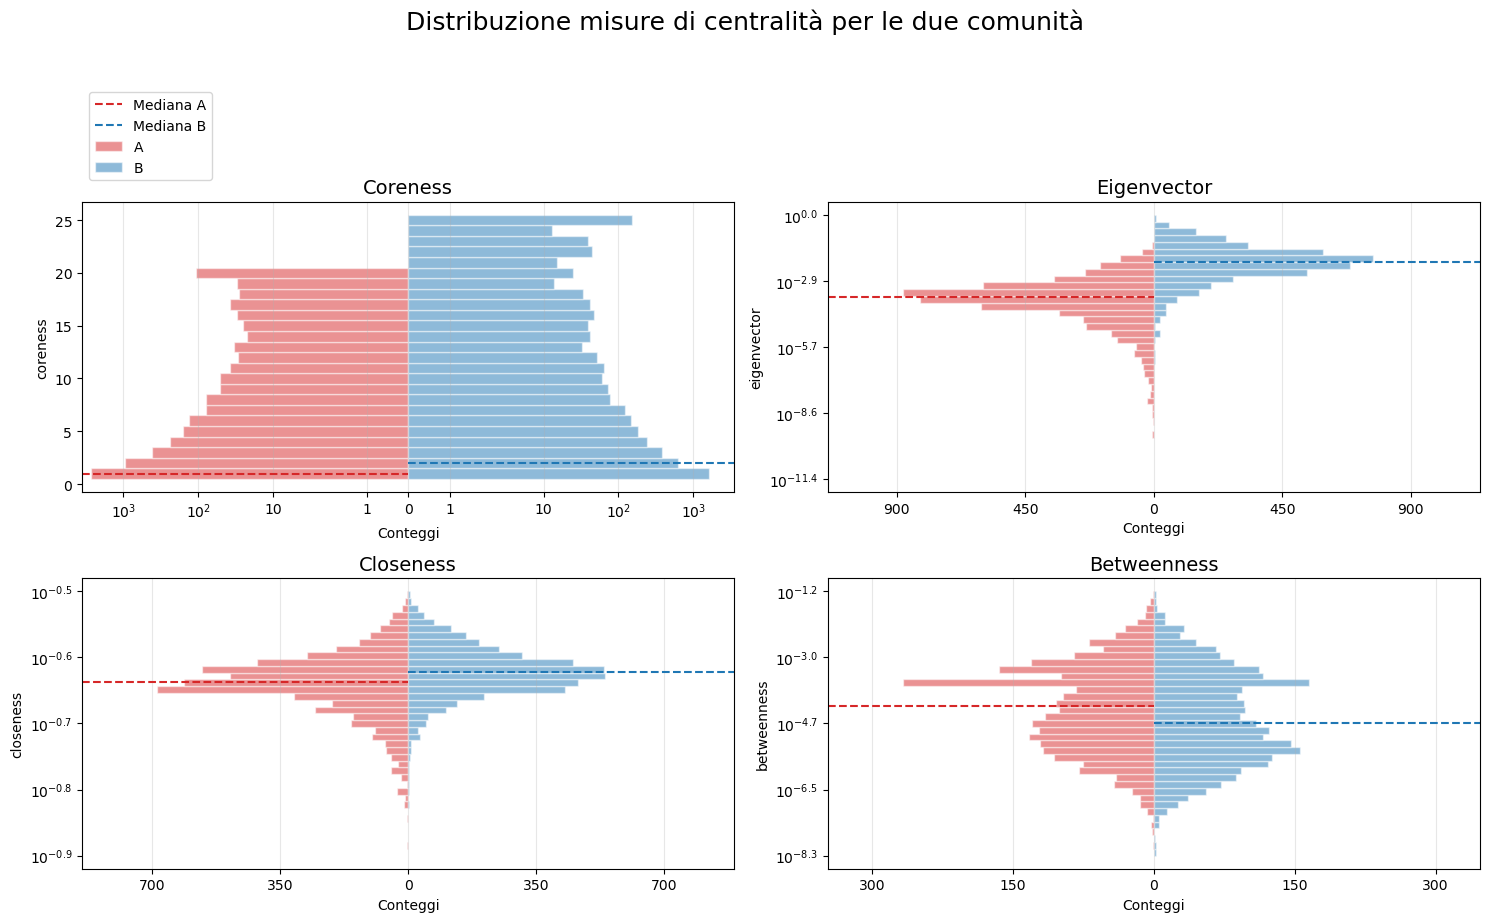

In [35]:
plot_centralities(G)

Dal grafico estrapoliamo le seguenti informazioni sulla rete.
- **Coreness**: Per entrambe le comunità dominano fortemente i core più piccoli, ovvero la grande maggioranza dei nodi si concentra nei primi due k-core. Il gruppo B ha molti più nodi nei k-core più alti arrivando a formare un picco locale in k=25, a differenza di A in cui si limitano a k=20.
Si può dedurre che B abbia un core più denso e connesso, ovvero una struttura a camera d'eco in cui i nodi si rinforzano a vicenda. Mentre A presenta una struttura meno organizzata con più nodi periferici.

- **Eigenvector**: Notiamo come la mediana di B sia di due ordini di grandezza più alta della mediana di A. Questo siginifica che i nodi di B sono significativamente più vicini a nodi influenti, che rinforza le considerazioni precedenti. 

- **Closeness**: La mediana di A e B sono confrontabili. A ha una coda più pesante verso valori più bassi di closeness e questo indica che la comunità è meno accentrata intorno al suo core, ovvero ci sono molti nodi periferici lontani dai nodi più importanti.

- **Betweenness**: In questo caso, A ha la mediana più alta. Questo può essere dovuto al fatto che A è ha una struttura meno connessa, quindi i nodi che ne connettono le parti hanno una betweenness maggiore. B invece ha una struttura ridondante nei cammini con più nodi a valori bassi.

Per comprendere come le centralità sono legate tra loro, riportiamo il grafico della matrice di Spearman.

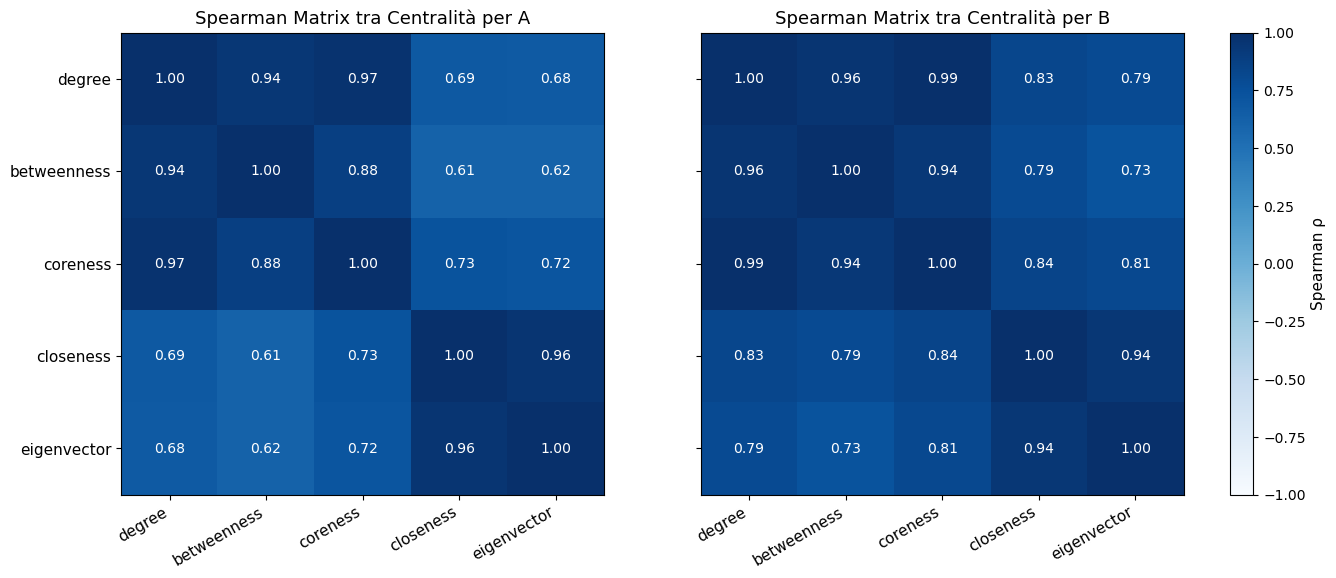

In [117]:
from scipy.stats import spearmanr
import matplotlib.colors as mcolors

def spearman(centralities: dict):
    '''Prende il dizionario con le centralità e restituisce la matrice di Spearmanr'''
    labels = list(centralities.keys())
    n = len(labels)
    data = np.array([centralities[k] for k in labels])  # shape (4, n_nodes)

    # Matrice di correlazione di Spearman 
    corr_matrix = np.ones((n, n))
    pval_matrix = np.ones((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            r, p = spearmanr(data[i], data[j])
            corr_matrix[i, j] = r
            corr_matrix[j, i] = r
            pval_matrix[i, j] = p
            pval_matrix[j, i] = p
    return corr_matrix, labels   


fig, ax = plt.subplots(1, 2, figsize=FIGSIZE_LARGE, sharey=True)

for k, groups in enumerate(GROUP):
    # Separa i due gruppi
    mask = [group == groups for group in G.vs['group']]


    # Calcola le centralità in un dizionario
    centralities = {
        'degree':      np.array(G.vs['degree'])[mask],
        'betweenness': np.array(G.vs['betweenness'])[mask],
        'coreness':    np.array(G.vs['coreness'])[mask],
        'closeness':   np.array(G.vs['closeness'])[mask],
        'eigenvector': np.array(G.vs['eigenvector'])[mask]
    }



    corr_matrix, labels = spearman(centralities)
    n = len(labels)

    # Colormap divergente centrata su 0
    vmin, vmax = -1, 1
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    im = ax[k].imshow(corr_matrix, cmap=CMAP_HEAT, norm=norm, aspect='auto')
    # Colorbar
    if k==0:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Spearman ρ", fontsize=11)


    # Etichette assi
    ax[k].set_xticks(range(n))
    ax[k].set_yticks(range(n))
    ax[k].set_xticklabels(labels, rotation=30, ha='right', fontsize=11)
    ax[k].set_yticklabels(labels, fontsize=11)
    ax[k].set_title("Spearman Matrix tra Centralità per " + groups, fontsize=13)
    
    low = corr_matrix.min() if vmin is None else vmin
    high = corr_matrix.max() if vmax is None else vmax
    threshold = (low + high) / 2.0 if high > low else high
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            value = corr_matrix[i, j]
            text_color = 'white' if value >= threshold else 'black'
            ax[k].text(
                j,
                i,
                f"{value:.2f}",
                ha='center',
                va='center',
                color=text_color,
            )
        
plt.show()

plt.close(fig)        

Notiamo come in B ci siano delle correlazioni maggiori rispetto ad A in quasi tutte le metriche, in particolare:
- **Closeness - Degree**: in B la correlazione è alta (0.83), quindi nodi strutturamente vicini agli altri sono quelli con alto grado. In A questo legame è meno forte (0.69): questo significa che in A puoi avere grado alto ma essere più periferico. Questo individua in A una struttura frammentata in componenti. 
- **Degree - Eigenvector**: analogamente, in B (0.79) nodi con alto degree sono connessi a nodi importanti, ovvero gli hub della rete sono connessi tra loro. In A (0.68) puoi avere alto grado ma essere connesso a nodi periferici, elemento a riprova della struttura frammentata di A.
- **Betweenness - Coreness/Closeness**: in B chi è un ponte efficace è sia un nodo che fa parte del core denso che un nodo ben posizionato globalmente. In A puoi essere un bridge anche se sei strutturamente lontano dal core e quindi anche se fai parte della struttura più periferica.


In [ ]:
def plot_metric_vs_metric_AB(G, metric_x, metric_y, metric_size=None):
    fig, ax = plt.subplots(figsize=FIGSIZE, sharex=True, layout='tight')
    for gr in GROUP:
        mask = [group == gr for group in G.vs['group']]
        size_min, size_max = 12, 240

        x = np.array(G.vs[metric_x])
        y = np.array(G.vs[metric_y])
        z = np.array(G.vs[metric_x])[mask]
        if metric_size:
            s = np.interp(z, (z.min(), z.max()), (size_min, size_max))
        else:
            s = 12    
        ax.scatter(x[mask], y[mask], s=s, alpha=0.4, color=color_group[gr], label=gr)
        ax.set_title(f'{metric_y} vs {metric_x}', fontsize=FONTSIZE_TITLE)
        ax.set_xlabel(metric_x)
        ax.set_ylabel(metric_y)
        ax.legend()
        ax.set_xscale('log')
        ax.set_yscale('log')



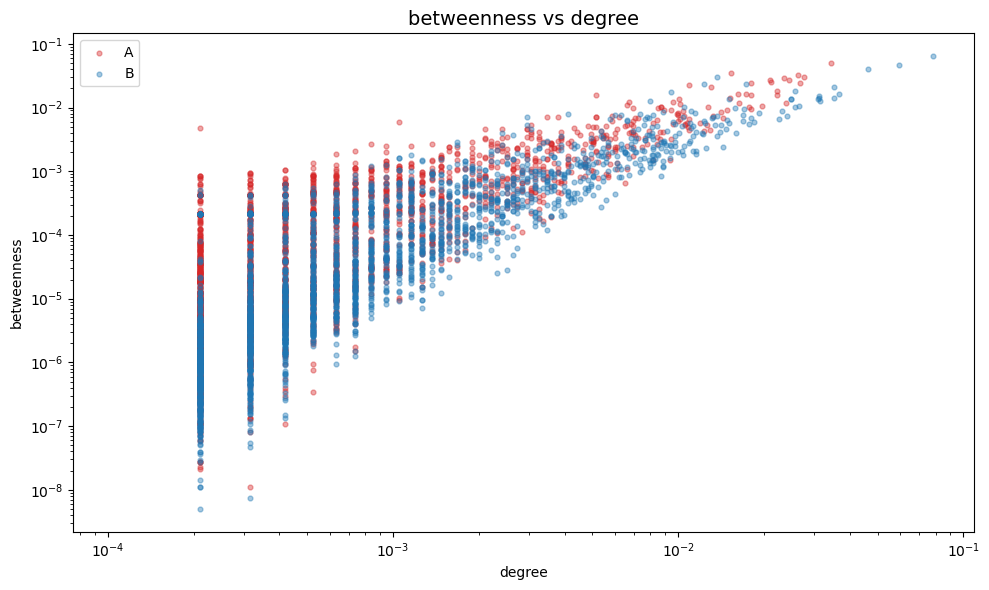

In [116]:
plot_metric_vs_metric_AB(G, 'degree', 'betweenness')

## domani:
- permutazioni label e assortatività